In [ ]:
#Võ Hoàn Lạc

In [ ]:
#Tiền xử lý dữ liệu
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
#  Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

DATA_DIR = "/content/drive/MyDrive/datadoan/plant-health" # Corrected path to the class subfolders

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = dataset.classes
print("Classes:", class_names)


Mounted at /content/drive
Classes: ['healthy', 'unhealthy']


In [ ]:
# Load ảnh và gán label
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define IMG_SIZE as it's used in this cell but not yet defined in the kernel state.
IMG_SIZE = (224, 224)

data = []
labels = []
#Resize về 244x244
#Gán : Healthy = 0, Stressed = 1
for label, cls in enumerate(class_names):
  #Xác định đường dẫn thư mục ảnh
    folder = os.path.join(DATA_DIR, cls)
    #Kiểm tra thư mục có tồn tại, nếu có bỏ qua tiếp tục
    if not os.path.isdir(folder):
        print(f"Warning: Directory not found: {folder}")
        continue
        #Duyệt ảnh trong từng thư mục và lấy danh sách tên các file ảnh trong thư mục
    for img_name in os.listdir(folder):
        #Tạo đường dẫn đầy đủ tới đến từng ảnh
        img_path = os.path.join(folder, img_name)
         #Đọc ảnh bằng OpenCV
        img = cv2.imread(img_path)
       #Kiểm tra anh đọc có thành công không
       #Nếu ảnh sai định dạng bỏ qua, in báo cáo
        if img is None:
            print(f"Warning: Could not read image {img_path}")
            continue
        #Chuyển không gian màu BGR thành RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        #Risize về kích thước chuẩn, đưa tất cả về kích thước 244x244
        img = cv2.resize(img, IMG_SIZE) # Fixed: Changed (IMG_SIZE, IMG_SIZE) to IMG_SIZE
        #Lưu ảnh đã xử lý vào date, lưu nhãn vào label
        data.append(img)
        labels.append(label)

X = np.array(data, dtype="float32")
y = np.array(labels)


In [ ]:
X = X / 255.0
#Sau khi đọc ảnh, dữ liệu được chuẩn hoá bằng cách chia giá trị pixel cho 255.0 nhằm đưa tất cả giá trị về khoảng [0, 1].
#Việc chuẩn hoá giúp quá trình huấn luyện mô hình học sâu ổn định hơn, tăng tốc độ hội tụ và phù hợp với các mô hình pretrained như ResNet.


In [ ]:
#CHIA TRAIN / VALIDATION / TEST
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


In [ ]:
#TĂNG CƯỜNG DỮ LIỆU
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    #Xoay ảnh ngẫu nhiên trong khoảng -30 đến 30 độ
    rotation_range=30,
    #Phóng to thu anh nhỏ ngẫu nhiêu từ -20% đến 20%
    zoom_range=0.2,
    #Lật ảnh theo chiều ngang
    horizontal_flip=True
)

datagen.fit(X_train)


In [ ]:
#TRÍCH XUẤT ĐẶC TRƯNG BẰNG RESNET50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
#KHởi tạo ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
#Không cập nhập trọng số ResNet trong quán trình train
for layer in base_model.layers:
    layer.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
#Gắn classifier
#Lấy đầu ra
x = base_model.output
x = Flatten()(x)
#Chống Overfitting
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
#Phân loại nhị phân
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
#COMPILE & TRAIN
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 140s 8s/step - accuracy: 0.5093 - loss: 3.4905 - val_accuracy: 0.5377 - val_loss: 0.8720
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 155s 9s/step - accuracy: 0.5571 - loss: 0.8902 - val_accuracy: 0.6132 - val_loss: 0.6656
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 129s 8s/step - accuracy: 0.5910 - loss: 0.7669 - val_accuracy: 0.6887 - val_loss: 0.5725
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 123s 8s/step - accuracy: 0.6667 - loss: 0.6490 - val_accuracy: 0.6981 - val_loss: 0.6708
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 130s 8s/step - accuracy: 0.6486 - loss: 0.6853 - val_accuracy: 0.6132 - val_loss: 0.6654
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 123s 8s/step - accuracy: 0.6710 - loss: 0.6987 - val_accuracy: 0.7075 - val_loss: 0.5954
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 124s 8s/step - accuracy: 0.6364 - loss: 0.7433 - val_accuracy: 0.6321 - val_loss: 0.6668
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 123s 8s/step - accuracy: 0.6322 - loss: 0.7679 - val_accuracy: 0.6792 - v

In [ ]:
#FINE-TUNING RESNET
import tensorflow as tf
#Chỉ mở 30 layer cuối của ResNet
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=10
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 203s 11s/step - accuracy: 0.5901 - loss: 0.9815 - val_accuracy: 0.7075 - val_loss: 0.5505
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 169s 11s/step - accuracy: 0.5953 - loss: 0.6655 - val_accuracy: 0.7642 - val_loss: 0.4919
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 188s 12s/step - accuracy: 0.6501 - loss: 0.6565 - val_accuracy: 0.6509 - val_loss: 0.6133
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 186s 12s/step - accuracy: 0.7250 - loss: 0.5672 - val_accuracy: 0.6415 - val_loss: 0.8047
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 167s 10s/step - accuracy: 0.7753 - loss: 0.4951 - val_accuracy: 0.6226 - val_loss: 0.9379
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 167s 10s/step - accuracy: 0.7772 - loss: 0.4810 - val_accuracy: 0.6226 - val_loss: 0.9342
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 202s 10s/step - accuracy: 0.7738 - loss: 0.4311 - val_accuracy: 0.6226 - val_loss: 0.8590
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 203s 11s/step - accuracy: 0.7868 - loss: 0.4411 - val_accuracy: 0.

In [ ]:
#ĐÁNH GIÁ MÔ HÌNH
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.7140 - loss: 0.5970
Test Accuracy: 0.672897219657898


In [ ]:
#Confusion Matrix & Report
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=class_names))
print(confusion_matrix(y_test, y_pred))


4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step
              precision    recall  f1-score   support

     healthy       0.94      0.31      0.46        49
   unhealthy       0.63      0.98      0.77        58

    accuracy                           0.67       107
   macro avg       0.78      0.64      0.61       107
weighted avg       0.77      0.67      0.63       107

[[15 34]
 [ 1 57]]


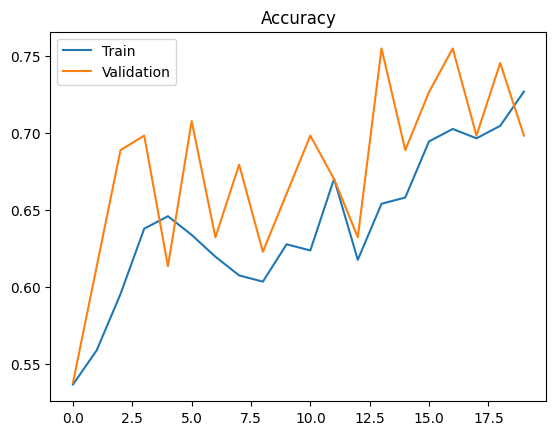

In [ ]:
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title("Accuracy")
  plt.legend(["Train","Validation"])
  plt.show()
